Not: Modelin asıl eğitimi ve performans optimizasyonları bu dosya üzerinden yürütülmüştür. Uzun süren eğitim süreçleri içerdiği için bazı hücre çıktıları son çalışma anına aittir.

In [5]:
import torch

print("PyTorch Versiyonu:", torch.__version__)
print("CUDA (Ekran Kartı Desteği) Aktif mi?:", torch.cuda.is_available())

if torch.cuda.is_available():
    cihaz_adi = torch.cuda.get_device_name(0)
    print(f"Harika! {cihaz_adi} başarıyla algılandı ve eğitime hazır. 🚀")
else:
    print("Sistem hala sadece işlemciyi (CPU) görüyor.")

PyTorch Versiyonu: 2.6.0+cu124
CUDA (Ekran Kartı Desteği) Aktif mi?: True
Harika! NVIDIA GeForce RTX 3080 başarıyla algılandı ve eğitime hazır. 🚀


In [22]:
import pandas as pd
import os

# CSV dosyamızın yolu (İsmini kendi dosyana göre düzenle lütfen)
csv_yolu = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\Veri_seti\veri_seti.csv" 
# ÖRNEK: Eğer dosyanın adı bmi.csv ise burayı "veri_seti/bmi.csv" yap

# Veriyi Pandas ile okuyup ilk 5 satırına bakalım
df = pd.read_csv(csv_yolu)
print(f"Toplam Veri Sayısı: {len(df)}")
print("-" * 30)
df.head()

Toplam Veri Sayısı: 50
------------------------------


,id,UID,name,height,weight
0,1,akshay,akshay kumar,1.78,80
1,2,ja,john abraham,1.82,94
2,3,varun,varun dhawan,1.68,78
3,4,tiger,Tiger shroff,1.75,72
4,5,salman,Salman khan,1.74,75


Eğitim için taranan TOPLAM fotoğraf sayısı: 257
----------------------------------------


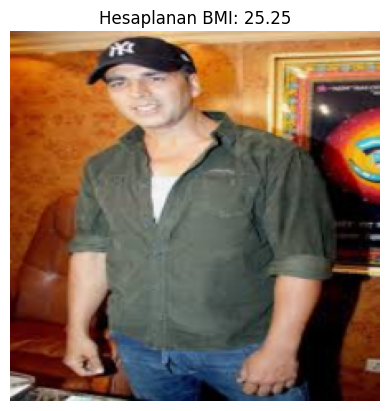

In [25]:
import os
import glob
import re  # Kelimelerin içindeki rakamları silmek için kullanacağımız araç
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. Dosya yollarımız
csv_yolu = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\Veri_seti\veri_seti.csv"
resim_klasoru = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\Veri_seti\sample_faces"

# Veriyi okuyup UID sütununu temizleyelim (küçük harf yapıp boşlukları silelim)
df = pd.read_csv(csv_yolu)
df['UID'] = df['UID'].str.strip().str.lower()

class BmiDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        
        # Klasördeki TÜM resim dosyalarını bul
        tum_dosyalar = glob.glob(os.path.join(img_dir, "*.*"))
        gecerli_uzantilar = ['.jpg', '.jpeg', '.png']
        
        # Sadece geçerli resim uzantılarını listeye al
        self.resim_yollari = [yol for yol in tum_dosyalar if os.path.splitext(yol)[1].lower() in gecerli_uzantilar]

    def __len__(self):
        # Artık veri sayımız Excel'deki kişi sayısı değil, klasördeki TOPLAM FOTOĞRAF sayısı!
        return len(self.resim_yollari)

    def __getitem__(self, idx):
        foto_yol = self.resim_yollari[idx]
        
        # 1. Fotoğraf isminden kişiyi bulalım (Örn: "akshay14.jpeg" -> "akshay")
        dosya_adi = os.path.basename(foto_yol)          # "akshay14.jpeg"
        isim_kismi = os.path.splitext(dosya_adi)[0]     # "akshay14"
        
        # İçindeki rakamları silelim ("akshay14" -> "akshay")
        uid = re.sub(r'\d+', '', isim_kismi).strip().lower()
        
        # 2. Excel'de bu kişiyi bulalım
        kisi_verisi = self.dataframe[self.dataframe['UID'] == uid]
        
        # Eğer kişi Excel'de yoksa hata ver
        if len(kisi_verisi) == 0:
            raise ValueError(f"HATA: '{uid}' isimli kişi Excel tablosunda bulunamadı! Dosya: {dosya_adi}")
            
        satir = kisi_verisi.iloc[0]
        
        # 3. BMI Hesapla
        kilo = float(satir['weight'])
        boy = float(satir['height'])
        bmi = kilo / (boy ** 2)
        
        # 4. Fotoğrafı aç
        image = Image.open(foto_yol).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(bmi, dtype=torch.float32)

# Modeli besleyeceğimiz standart boyutlandırma
donusum = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Sistemi Başlat
ozel_veri_setimiz = BmiDataset(dataframe=df, img_dir=resim_klasoru, transform=donusum)

# Test edelim!
print(f"Eğitim için taranan TOPLAM fotoğraf sayısı: {len(ozel_veri_setimiz)}")
print("-" * 40)

ilk_foto, ilk_bmi = ozel_veri_setimiz[0]

plt.imshow(ilk_foto.permute(1, 2, 0))
plt.title(f"Hesaplanan BMI: {ilk_bmi.item():.2f}")
plt.axis('off')
plt.show()

In [26]:
import torch.nn as nn
import torch.nn.functional as F

# 1. Yapay Zeka Modelimizin Beynini (Mimarisini) Tanımlıyoruz
class BmiTahminCNN(nn.Module):
    def __init__(self):
        super(BmiTahminCNN, self).__init__()
        
        # --- ÖZELLİK ÇIKARICI KATMANLAR (Fotoğrafa bakıp yüz hatlarını, şekilleri öğrenen kısım) ---
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # --- KARAR VERİCİ KATMANLAR (Öğrenilen özelliklerden BMI sayısını hesaplayan kısım) ---
        # 224x224 piksel fotoğraf, 3 kez havuzlama (pool) işleminden geçince boyutu 28x28'e düşer.
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 128)
        
        # ÇIKIŞ KATMANI: Neden sadece 1? 
        # Çünkü sadece tek bir sayı (BMI değeri) tahmin edeceğiz!
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        # Fotoğrafı katmanlardan sırayla geçiriyoruz
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Düzleştirme (Flatten): Matrisi tek boyutlu bir listeye çeviriyoruz
        x = x.view(-1, 64 * 28 * 28)
        
        # Karar katmanlarından geçiriyoruz
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Son katmanda kısıtlama yok, çünkü BMI herhangi bir sayı olabilir
        return x

# 2. Cihaz Seçimi: Ekran Kartını (RTX 3080) Göreve Çağırıyoruz
cihaz = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Modeli Oluştur ve Ekran Kartına Gönder
model = BmiTahminCNN().to(cihaz)

print(f"Harika! Model başarıyla oluşturuldu ve {cihaz} üzerine yerleştirildi. 🚀")
print("-" * 40)
print(model)

Harika! Model başarıyla oluşturuldu ve cuda üzerine yerleştirildi. 🚀
----------------------------------------
BmiTahminCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
#küçük veri eğitimi
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Veri Paketleyici (DataLoader)
# 257 fotoğrafı tek seferde değil, ekran kartının VRAM'ini şişirmemek için 16'şarlı paketler halinde gönderiyoruz.
paket_boyutu = 16 
egitim_yukleyici = DataLoader(ozel_veri_setimiz, batch_size=paket_boyutu, shuffle=True)

# 2. Hata Ölçer (Loss Function) ve Öğretmen (Optimizer)
# Sayı (BMI) tahmini yaptığımız için MSE (Ortalama Karesel Hata) kullanıyoruz.
hata_fonksiyonu = nn.MSELoss()

# Adam algoritması, modelin yaptığı hatalardan en hızlı ders çıkarmasını sağlayan modern bir optimizasyon aracıdır.
optimizator = optim.Adam(model.parameters(), lr=0.001)

# 3. Eğitim Döngüsü (Epochs)
# Epoch: Modelin tüm veri setini (257 fotoğrafı) baştan sona kaç kez göreceği.
epoch_sayisi = 10 

print("Eğitim Başlıyor... RTX 3080 motorları çalıştırdı! 🚀")
print("-" * 50)

for epoch in range(epoch_sayisi):
    toplam_hata = 0.0
    
    # Her bir 16'lı fotoğraf paketini sırayla alıyoruz
    for batch_idx, (fotograflar, gercek_bmi) in enumerate(egitim_yukleyici):
        
        # a. Verileri İşlemciden (RAM) Ekran Kartına (VRAM) Taşı
        fotograflar = fotograflar.to(cihaz)
        gercek_bmi = gercek_bmi.to(cihaz)
        
        # Boyut uyumsuzluğunu önlemek için (16,) olan listeyi (16, 1) şekline getiriyoruz
        gercek_bmi = gercek_bmi.view(-1, 1)

        # b. İleri Yayılım (Tahmin Yap)
        tahminler = model(fotograflar)
        
        # c. Hatayı Hesapla (Gerçek BMI ile Tahmin Edilen BMI arasındaki fark)
        hata = hata_fonksiyonu(tahminler, gercek_bmi)
        
        # d. Geri Yayılım (Öğrenme Aşaması)
        optimizator.zero_grad() # Bir önceki paketin hafızasını temizle
        hata.backward()         # Hatayı ağın içine geriye doğru dağıt (Türev al)
        optimizator.step()      # Ağırlıkları güncelleyerek modeli biraz daha akıllandır
        
        toplam_hata += hata.item()
        
    # Her turun sonunda o turun ortalama hatasını ekrana yazdır
    ortalama_hata = toplam_hata / len(egitim_yukleyici)
    print(f"Tur (Epoch) [{epoch+1}/{epoch_sayisi}] - Hata Skoru (MSE): {ortalama_hata:.4f}")

print("-" * 50)
print("Eğitim Tamamlandı! 🎉 Modelimiz artık yüzlerden BMI tahmini yapmayı öğrendi.")

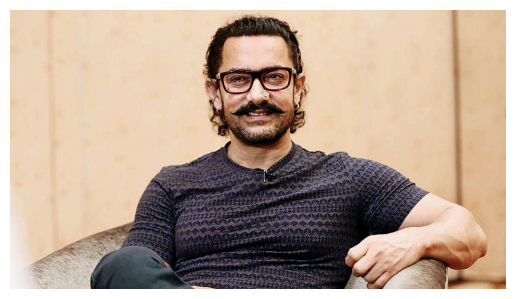

🤖 Yapay Zeka Tahmini - Vücut Kitle İndeksi (BMI): 25.9
--------------------------------------------------
🍽️ BESLENME VE VÜCUT ANALİZİ Raporu:
Durum: Fazla Kilolu (Hafif Yağlı)
Yorum: Bu BMI seviyesi, günlük kalori ihtiyacının biraz üzerinde beslenildiğini gösterir. Diyetteki işlenmiş karbonhidrat veya yağ tüketimi (örn: %40 civarı) standartların üzerinde olabilir.
--------------------------------------------------


In [29]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# 1. Modeli "Test" moduna alıyoruz (Artık öğrenme yapmayacak, sadece bildiklerini kullanacak)
model.eval()

def diyet_ve_bmi_analizi(fotograf_yolu):
    # 2. Fotoğrafı aç ve ekranda göster
    img = Image.open(fotograf_yolu).convert("RGB")
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    # 3. Fotoğrafı modelin anlayacağı formata (224x224 Tensor) çevir
    # unsqueeze(0) komutu, tek bir fotoğrafı "1'lik bir paket" haline getirir
    img_tensor = donusum(img).unsqueeze(0).to(cihaz) 
    
    # 4. Modeli çalıştır ve tahmini al
    with torch.no_grad(): # Test sırasında gradyan hesaplamaya (öğrenmeye) gerek yok, VRAM tasarrufu sağlarız
        tahmin = model(img_tensor)
        tahmin_edilen_bmi = tahmin.item()
        
    print(f"🤖 Yapay Zeka Tahmini - Vücut Kitle İndeksi (BMI): {tahmin_edilen_bmi:.1f}")
    
    # 5. Projenin Başındaki Orijinal İsteğin: Yorumlama Kısmı
    print("-" * 50)
    print("🍽️ BESLENME VE VÜCUT ANALİZİ Raporu:")
    
    if tahmin_edilen_bmi < 18.5:
        print("Durum: Zayıf (Düşük Yağ Oranı)")
        print("Yorum: Bu vücut tipine sahip bireyler genellikle kalori açığı yaratacak şekilde beslenmektedir. Diyetlerinde yağ oranının çok düşük (örn: %15-20) olduğu veya metabolizmalarının çok hızlı çalıştığı tahmin edilmektedir.")
    
    elif 18.5 <= tahmin_edilen_bmi < 25.0:
        print("Durum: Normal Kilolu")
        print("Yorum: Dengeli bir vücut yapısı. Muhtemelen protein, karbonhidrat ve yağ makroları orantılı, standart bir diyet (örn: %30 Yağ, %50 Karbonhidrat, %20 Protein) izleniyor.")
    
    elif 25.0 <= tahmin_edilen_bmi < 30.0:
        print("Durum: Fazla Kilolu (Hafif Yağlı)")
        print("Yorum: Bu BMI seviyesi, günlük kalori ihtiyacının biraz üzerinde beslenildiğini gösterir. Diyetteki işlenmiş karbonhidrat veya yağ tüketimi (örn: %40 civarı) standartların üzerinde olabilir.")
    
    else:
        print("Durum: Obezite (Yüksek Yağ Oranı)")
        print("Yorum: Bu vücut tipi, genellikle uzun süreli yüksek kalorili, yüksek yağlı (örn: %50+) ve basit şeker ağırlıklı beslenme alışkanlıklarıyla ilişkilendirilir.")
    print("-" * 50)

# ---------------------------------------------------------
# TEST ETMEK İÇİN: Modelin eğitim sırasında HİÇ GÖRMEDİĞİ yeni bir fotoğrafın yolunu buraya yaz!
# İstersen kendi fotoğrafını veya internetten indirdiğin rastgele bir fotoğrafı koyabilirsin.
test_fotografi = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\Veri_seti\sample_faces\amir1.jpg" # Ben örnek olarak klasörden bir tane seçtim
diyet_ve_bmi_analizi(test_fotografi)

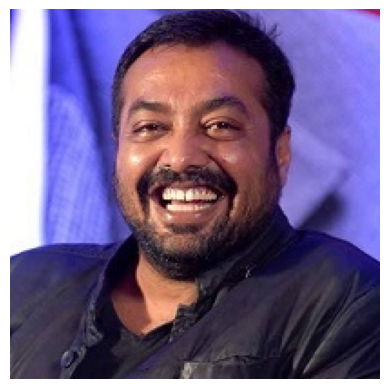

🤖 Yapay Zeka Tahmini - Vücut Kitle İndeksi (BMI): 26.4
------------------------------------------------------------
📊 DÜNYA SAĞLIK ÖRGÜTÜ (WHO) BMI KATEGORİSİ:
Kategori: Fazla Kilolu
*(Not: Sporcularda ve kas kütlesi yüksek bireylerde bu değer yağ oranını yansıtmayabilir.)*
------------------------------------------------------------


In [32]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

model.eval()

def sadece_bmi_analizi(fotograf_yolu):
    # Fotoğrafı aç ve göster
    img = Image.open(fotograf_yolu).convert("RGB")
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    # Model için hazırla
    img_tensor = donusum(img).unsqueeze(0).to(cihaz) 
    
    # Tahmini al
    with torch.no_grad():
        tahmin = model(img_tensor)
        tahmin_edilen_bmi = tahmin.item()
        
    print(f"🤖 Yapay Zeka Tahmini - Vücut Kitle İndeksi (BMI): {tahmin_edilen_bmi:.1f}")
    
    # Objektif ve Bilimsel Çıktı
    print("-" * 60)
    print("📊 DÜNYA SAĞLIK ÖRGÜTÜ (WHO) BMI KATEGORİSİ:")
    
    if tahmin_edilen_bmi < 18.5:
        print("Kategori: Zayıf")
    elif 18.5 <= tahmin_edilen_bmi < 25.0:
        print("Kategori: Normal Kilolu")
    elif 25.0 <= tahmin_edilen_bmi < 30.0:
        print("Kategori: Fazla Kilolu")
        print("*(Not: Sporcularda ve kas kütlesi yüksek bireylerde bu değer yağ oranını yansıtmayabilir.)*")
    else:
        print("Kategori: Obezite")
    print("-" * 60)

# Kodu test edelim
test_fotografi = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\Veri_seti\sample_faces\anurag1.jpg"
sadece_bmi_analizi(test_fotografi)

In [33]:
# Kaydedilecek dosyanın adını belirliyoruz
kayit_yolu = "bmi_yapay_zeka_modelim.pth"

# Modelin "öğrendiği bilgileri" (ağırlıkları) bu dosyaya yazıyoruz
torch.save(model.state_dict(), kayit_yolu)

print(f"🎉 Başarılı! Modelin beyni '{kayit_yolu}' adıyla bilgisayarına kaydedildi.")

🎉 Başarılı! Modelin beyni 'bmi_yapay_zeka_modelim.pth' adıyla bilgisayarına kaydedildi.


In [ ]:
# 1. Boş bir model iskeleti oluştur ve ekran kartına yolla
yuklenen_model = BmiTahminCNN().to(cihaz)

# 2. Kaydettiğimiz beyni (ağırlıkları) bu iskelete yükle
yuklenen_model.load_state_dict(torch.load(r"C:\Users\emirh\Desktop\machlearn\faces\bmi_yapay_zeka_modelim.pth"))

# 3. Modeli sadece test/kullanım moduna al (Öğrenmeyi kapat)
yuklenen_model.eval()

print("Model başarıyla uyandırıldı ve teste hazır! 🤖")

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import gradio as gr
import os

# 1. KAPANIP AÇILMA SONRASI HAFIZAYI TAZELEME (İskelet ve Cihaz Kurulumu)
class BmiTahminCNN(nn.Module):
    def __init__(self):
        super(BmiTahminCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

cihaz = torch.device("cuda" if torch.cuda.is_available() else "cpu")

donusum = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 2. KAYDEDİLMİŞ BEYNİ YÜKLEME (Senin düzelttiğin dosya yolu ile)
# r harfi tırnağın dışında!
model_dosyasi = r"C:\Users\emirh\Desktop\machlearn\faces\bmi_yapay_zeka_modelim.pth" 

model_gui = BmiTahminCNN().to(cihaz)
model_gui.load_state_dict(torch.load(model_dosyasi))
model_gui.eval() # Test moduna al

print("Model başarıyla uyandırıldı! Web arayüzü başlatılıyor... 🚀")

# 3. WEB ARAYÜZÜ İÇİN TAHMİN FONKSİYONU
def predict_bmi_gradio(inp_image):
    img_tensor = donusum(inp_image).unsqueeze(0).to(cihaz)
    
    with torch.no_grad():
        tahmin = model_gui(img_tensor)
        tahmin_edilen_bmi = tahmin.item()
        
    if tahmin_edilen_bmi < 18.5:
        kategori = "Zayıf"
    elif 18.5 <= tahmin_edilen_bmi < 25.0:
        kategori = "Normal Kilolu"
    elif 25.0 <= tahmin_edilen_bmi < 30.0:
        kategori = "Fazla Kilolu"
    else:
        kategori = "Obezite"
        
    rapor = f"""
### 📊 Yapay Zeka Analiz Raporu

**Tahmin Edilen BMI:** {tahmin_edilen_bmi:.1f}
**WHO Kategorisi:** **{kategori}**

***
*Not: Bu analiz yüz ve vücut hatlarına dayalı istatistiksel bir tahmindir. Kas kütlesi yüksek bireylerde BMI değeri yağ oranını doğrudan yansıtmayabilir.*
"""
    return rapor

# 4. ŞIK GRADIO ARAYÜZÜNÜN TASARIMI
baslik = "🤖 Fotoğraftan Vücut Analizi (BMI Tahmini)"
aciklama = "Yapay zekayı test etmek için bir insan fotoğrafı yükleyin. Modelimiz saniyeler içinde Vücut Kitle İndeksi (BMI) değerini ve Dünya Sağlık Örgütü kategorisini hesaplayacaktır."

arayuz = gr.Interface(
    fn=predict_bmi_gradio,              
    inputs=gr.Image(type="pil", label="Fotoğraf Yükle (Sürükle veya Seç)"), 
    outputs=gr.Markdown(label="Analiz Sonucu"),             
    title=baslik,
    description=aciklama,
    theme="soft" 
)

# Arayüzü VS Code içinde başlat
arayuz.launch(inline=True, share=False)

Model başarıyla uyandırıldı! Web arayüzü başlatılıyor... 🚀


c:\Users\emirh\AppData\Local\Programs\Python\Python311\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [7]:
import pandas as pd
# Yeni indirdiğin CSV dosyasının yolunu kopyalayıp buraya yapıştır
yeni_csv_yolu = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\buyuk_veri\visual_bmi_annotations.csv" 

df_buyuk = pd.read_csv(yeni_csv_yolu)
print(f"Yeni Veri Sayısı: {len(df_buyuk)}")
df_buyuk.head()

Yeni Veri Sayısı: 5897


,image_path,person_id,image_id,weight_lb,height_in,is_female,BMI
0,/kaggle/input/visual-bmi/bodyface_1to17/2a42h0...,2a42h0,h6VenpC,225.0,71.0,False,31.38
1,/kaggle/input/visual-bmi/bodyface_1to17/2a42h0...,2a42h0,z6VenpC,216.0,71.0,False,30.12
2,/kaggle/input/visual-bmi/bodyface_1to17/2xraoq...,2xraoq,PbDJbcx,213.0,66.0,True,34.38
3,/kaggle/input/visual-bmi/bodyface_1to17/2xraoq...,2xraoq,zbDJbcx,213.0,66.0,True,34.38
4,/kaggle/input/visual-bmi/bodyface_1to17/3xptz5...,3xptz5,P2YhThW,167.0,67.0,False,26.15


In [9]:
import os
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Klasör Yolları
ana_resim_klasoru = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\buyuk_veri" # Resimlerin ana ana klasörü

class BuyukBmiDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # image_path sütunundaki yolu alıyoruz: /kaggle/input/visual-bmi/bodyface_1to17/...
        # Baştaki gereksiz kısmı temizleyip kendi bilgisayarımızdaki yola çevirelim
        goreceli_yol = self.dataframe.iloc[idx]['image_path'].replace('/kaggle/input/visual-bmi/', '')
        foto_yol = os.path.join(self.root_dir, goreceli_yol)
        
        # Windows ters eğik çizgi düzeltmesi
        foto_yol = foto_yol.replace('/', os.sep)

        try:
            image = Image.open(foto_yol).convert("RGB")
        except Exception as e:
            # Eğer bir fotoğraf hatalıysa veya yoksa pas geçmek yerine hata versin ki görelim
            raise FileNotFoundError(f"Fotoğraf bulunamadı veya açılamadı: {foto_yol}")
        
        # BMI sütununu doğrudan alıyoruz
        bmi = float(self.dataframe.iloc[idx]['BMI'])
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(bmi, dtype=torch.float32)

# 2. Gelişmiş Eğitim Ayarları
donusum = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Profesyonel renk normalizasyonu
])

buyuk_veri_setimiz = BuyukBmiDataset(dataframe=df_buyuk, root_dir=ana_resim_klasoru, transform=donusum)

# 3. RTX 3080 için Hız Ayarı (Batch Size)
# 6000 fotoğraf için 32 veya 64 idealdir. VRAM'in yetmezse 32'ye düşürürüz.
egitim_yukleyici = DataLoader(buyuk_veri_setimiz, batch_size=32, shuffle=True)

print(f"Sistem Hazır! {len(buyuk_veri_setimiz)} fotoğraf eğitim kuyruğuna alındı. 🚀")

Sistem Hazır! 5897 fotoğraf eğitim kuyruğuna alındı. 🚀


In [14]:
# Sadece model yükleme kısmındaki dosya adını ve mimariyi güncelliyoruz
model_dosyasi = r"C:\Users\emirh\Desktop\machlearn\faces\diyet_projesi\bmi_model_buyuk_veri_v1.pth" 

# DİKKAT: Büyük veri eğitiminde kanal sayısını 32-64-128 yapmıştık!
# Mimari iskeleti eğitim kodundakiyle birebir aynı olmalı:
class BmiNet(nn.Module):
    def __init__(self):
        super(BmiNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Modeli yükle
model_gui = BmiNet().to(cihaz)
model_gui.load_state_dict(torch.load(model_dosyasi))
model_gui.eval()
print("Süper Model Uyandırıldı! 🚀")

Süper Model Uyandırıldı! 🚀
